# Pseudo-label Example Comparison

Use the project example (`KRR_covariate_shift`) to create comparisons similar to `KRR-CS-learn_l2norm.ipynb`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from KRR import KRR_covariate_shift

# Common setup
fcn = 'C'
sigma = 1
beta = 2
seed = 2026

n = 500
n_0 = n
B = 5
N_test = 10000

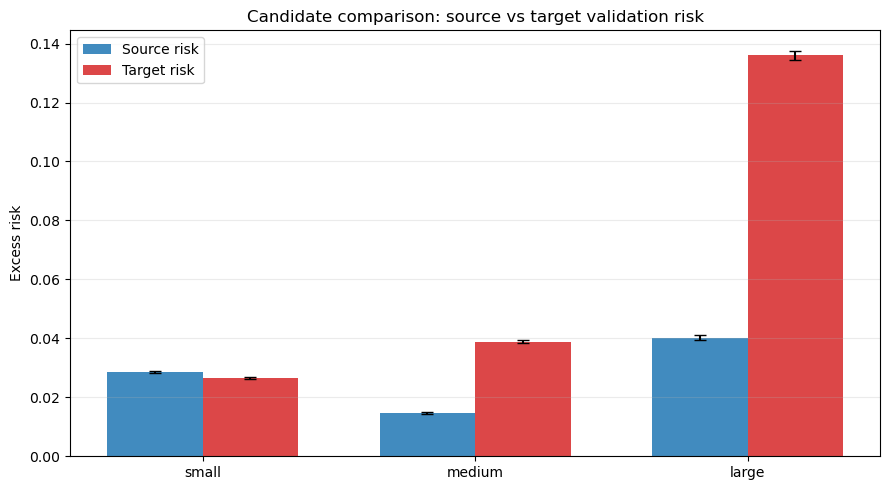

Source means: {'small': np.float64(0.028641), 'medium': np.float64(0.014622), 'large': np.float64(0.040285)}
Target means: {'small': np.float64(0.026493), 'medium': np.float64(0.038901), 'large': np.float64(0.13603)}


In [2]:
# Single run: compare candidate penalties on source vs target
test = KRR_covariate_shift(n, n_0, B, sigma, fcn, seed)
test.fit(beta=beta)

list_idx_candidates = [2, 4, 6]
labels = ['small', 'medium', 'large']

test.evaluate_candidates('source', list_idx_candidates, N_test=N_test, seed=seed)
source_mean = np.array(test.err_candidates)
source_ste = np.array(test.err_candidates_ste)

test.evaluate_candidates('target', list_idx_candidates, N_test=N_test, seed=seed)
target_mean = np.array(test.err_candidates)
target_ste = np.array(test.err_candidates_ste)

x = np.arange(len(labels))
w = 0.35

plt.figure(figsize=(9, 5))
plt.bar(x - w/2, source_mean, width=w, yerr=source_ste, capsize=4, label='Source risk', color='tab:blue', alpha=0.85)
plt.bar(x + w/2, target_mean, width=w, yerr=target_ste, capsize=4, label='Target risk', color='tab:red', alpha=0.85)
plt.xticks(x, labels)
plt.ylabel('Excess risk')
plt.title('Candidate comparison: source vs target validation risk')
plt.grid(alpha=0.25, axis='y')
plt.legend()
plt.tight_layout()
plt.show()

print('Source means:', dict(zip(labels, source_mean.round(6))))
print('Target means:', dict(zip(labels, target_mean.round(6))))

In [3]:
# Repeated simulation: compare selected models (naive / pseudo / oracle)
n_rep = 200
seeds = 1000 + np.arange(n_rep)

err_naive = []
err_pseudo = []
err_oracle = []

for s in seeds:
    exp = KRR_covariate_shift(n, n_0, B, sigma, fcn, int(s))
    exp.fit(beta=beta)
    exp.evaluate_final(N_test=N_test, seed=int(s))

    err_naive.append(exp.err_naive)
    err_pseudo.append(exp.err_pseudo)
    err_oracle.append(exp.err_real)

err_naive = np.array(err_naive)
err_pseudo = np.array(err_pseudo)
err_oracle = np.array(err_oracle)

print(f'Naive  mean={err_naive.mean():.6f}, std={err_naive.std():.6f}')
print(f'Pseudo mean={err_pseudo.mean():.6f}, std={err_pseudo.std():.6f}')
print(f'Oracle mean={err_oracle.mean():.6f}, std={err_oracle.std():.6f}')

Naive  mean=0.064469, std=0.049368
Pseudo mean=0.063926, std=0.055329
Oracle mean=0.053038, std=0.042574


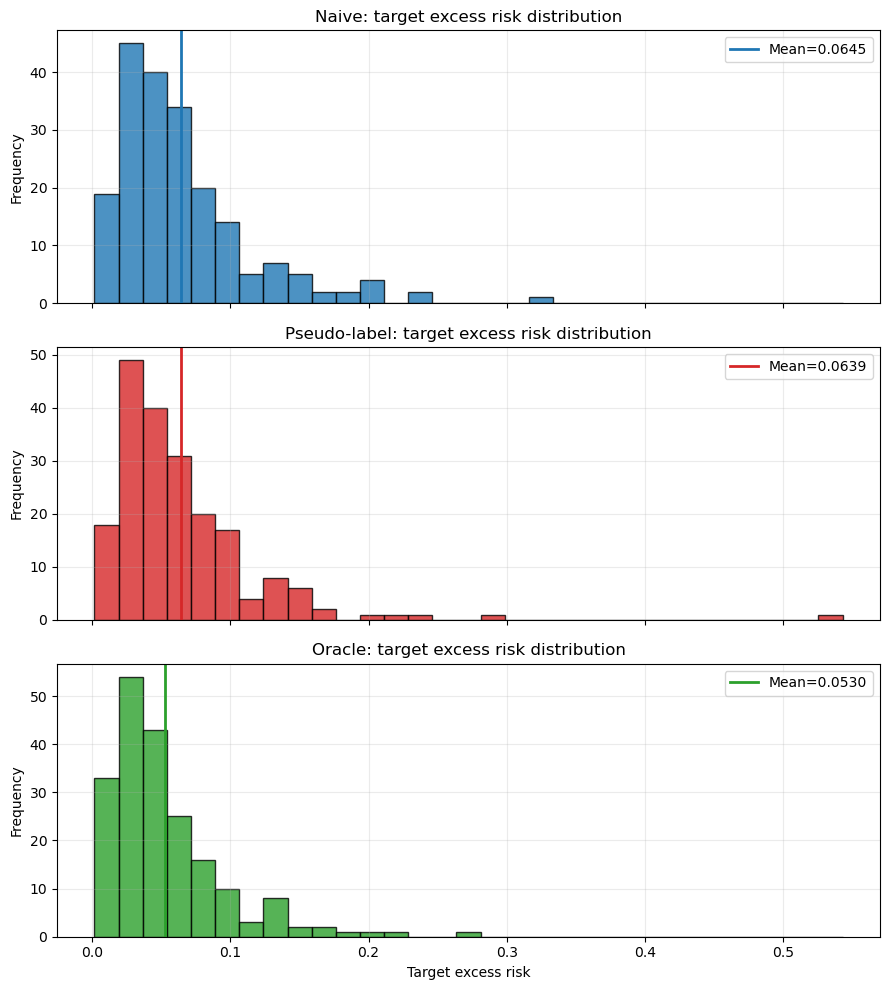

In [4]:
# Histogram comparison (style similar to your l2norm notebook)
all_vals = np.concatenate([err_naive, err_pseudo, err_oracle])
bins = np.linspace(all_vals.min(), all_vals.max(), 32)

fig, axes = plt.subplots(3, 1, figsize=(9, 10), sharex=True)

axes[0].hist(err_naive, bins=bins, color='tab:blue', alpha=0.8, edgecolor='black')
axes[0].axvline(err_naive.mean(), color='tab:blue', linewidth=2, label=f'Mean={err_naive.mean():.4f}')
axes[0].set_title('Naive: target excess risk distribution')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].hist(err_pseudo, bins=bins, color='tab:red', alpha=0.8, edgecolor='black')
axes[1].axvline(err_pseudo.mean(), color='tab:red', linewidth=2, label=f'Mean={err_pseudo.mean():.4f}')
axes[1].set_title('Pseudo-label: target excess risk distribution')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].grid(alpha=0.25)

axes[2].hist(err_oracle, bins=bins, color='tab:green', alpha=0.8, edgecolor='black')
axes[2].axvline(err_oracle.mean(), color='tab:green', linewidth=2, label=f'Mean={err_oracle.mean():.4f}')
axes[2].set_title('Oracle: target excess risk distribution')
axes[2].set_xlabel('Target excess risk')
axes[2].set_ylabel('Frequency')
axes[2].legend()
axes[2].grid(alpha=0.25)

plt.tight_layout()
plt.show()